### Análisis de los modelos

Librerías y modulos necesarios

In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.6/147.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Librerías
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression

# Módulos
from funciones import *

CONSTANTES

In [ ]:
# Id de los datos procesados en formato parquet, almacenados en drive
ID_DATOS = '1N9ucOBFVTi1A-LOU1UyqmU_-pUwR40SY'

In [ ]:
# Se cargan los datos
data = cargar_parquet_drive(ID_DATOS)
data

,Marca,Modelo,Precio(€),Adicional,Primera matriculación,Kilometraje(Km),Carburante,Transmisión,Potencia(Cv),Tracción,Cilindrada(Cc),Accidentado,Edad(Meses)
0,Peugeot,3008,17899,1.2 PureTech Allure,2019-12-27,54616,Gasolina,manual,130,delantera,1199,No,51
1,Renault,Captur,16999,1.3 TCe Intens,2020-10-27,32383,Gasolina,manual,131,delantera,1332,No,41
2,BMW,Serie 2,14799,218d,2014-12-29,117846,Diésel,manual,143,trasera,1995,No,112
3,Fiat,500X,13499,1.6 E-Torq City Cross,2018-07-17,50914,Gasolina,manual,110,delantera,1598,No,69
4,BMW,Serie 1,16799,116i M Sport,2018-06-27,66438,Gasolina,manual,110,trasera,1499,No,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,Dacia,Duster,8099,1.6 Ambiance 4x2,2011-06-30,78287,Gasolina,manual,105,delantera,1598,No,154
1806,Volkswagen,Golf VII,26570,2.0 TSI GTI Performance BlueMotion,2018-05-17,67529,Gasolina,automatico,245,delantera,1984,No,71
1807,BMW,X4,29799,xDrive 20d,2017-12-11,96327,Diésel,automatico,190,total (4x4),1995,No,76
1808,Dacia,Sandero,9099,0.9 TCe Stepway,2015-11-04,93196,Gasolina,manual,90,delantera,898,No,101


In [ ]:
# Análisis estadístico descriptivo
print("Estadísticas descriptivas de las características:")
print(data.describe())

# Visualización de la correlación
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r',center=0)
plt.title('Matriz de correlación de características')
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
data.rename(columns={'Precio(€)': 'Precio'}, inplace=True)


# ANOVA para Carburante
model_carburante = ols('Precio ~ C(Carburante)', data=data).fit()
anova_table_carburante = sm.stats.anova_lm(model_carburante, typ=2)
print("ANOVA para Carburante:")
print(anova_table_carburante)

ANOVA para Carburante:
                     sum_sq      df          F        PR(>F)
C(Carburante)  6.536875e+09     3.0  61.824537  4.773689e-38
Residual       6.365108e+10  1806.0        NaN           NaN


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Carburante', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Carburante')
plt.xlabel('Tipo de Carburante')
plt.ylabel('Precio')
plt.show()

In [ ]:
# ANOVA para Tracción
model_traccion = ols('Precio ~ C(Tracción)', data=data).fit()
anova_table_traccion = sm.stats.anova_lm(model_traccion, typ=2)
print("ANOVA para Tracción:")
print(anova_table_traccion)

ANOVA para Tracción:
                   sum_sq      df           F        PR(>F)
C(Tracción)  8.864102e+09     2.0  130.656415  1.018879e-53
Residual     6.119424e+10  1804.0         NaN           NaN


In [ ]:
# Crear un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tracción', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Tracción')
plt.xlabel('Tipo de Tracción')
plt.ylabel('Precio')
plt.show()

In [ ]:
# ANOVA para Transmisión
model_transmision = ols('Precio ~ C(Transmisión)', data=data).fit()
anova_table_transmision = sm.stats.anova_lm(model_transmision, typ=2)
print("ANOVA para Transmisión:")
print(anova_table_transmision)

ANOVA para Transmisión:
                      sum_sq      df           F         PR(>F)
C(Transmisión)  2.064595e+10     1.0  753.458942  5.931840e-139
Residual        4.954201e+10  1808.0         NaN            NaN


In [ ]:
# Crear un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmisión', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Transmisión')
plt.xlabel('Tipo de Transmisión')
plt.ylabel('Precio')
plt.show()

In [ ]:
# ANOVA para Marca
model_Marca = ols('Precio ~ C(Marca)', data=data).fit()
anova_table_Marca = sm.stats.anova_lm(model_Marca, typ=2)
print("ANOVA para Marca:")
print(anova_table_Marca)

In [ ]:
# Crear un boxplot
plt.figure(figsize=(50, 50))
sns.boxplot(x='Marca', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Marca')
plt.xlabel('Marcas')
plt.ylabel('Precio')
plt.show()

In [ ]:
# ANOVA para Modelo
model_Modelo = ols('Precio ~ C(Modelo)', data=data).fit()
anova_table_Modelo = sm.stats.anova_lm(model_Modelo, typ=2)
print("ANOVA para Modelo:")
print(anova_table_Modelo)

ANOVA para Modelo:
                 sum_sq      df          F         PR(>F)
C(Modelo)  4.821235e+10   254.0  13.431177  2.950333e-256
Residual   2.197561e+10  1555.0        NaN            NaN


In [ ]:
# Separación entre variables de entrada y objetivo
X = data.drop(columns=["Precio", "Accidentado", "Adicional", "Primera matriculación"])
y = data["Precio"]
# En la memoria explicamos el porqué no usamos las variables "Accidentado", "Adicional" y "Primera matriculación"

# Ahora aplicamos las transformaciones necesarias
X, scaler = transformData(X)
X = X.to_numpy()
y = y.to_numpy()

# Con los datos ya listos, separamos entre train y test
X_train, X_test, y_train, y_test = splitTrainTest(X, y)

In [ ]:
# ANÁLISIS DE VARIABLES DE JESUS

Generamos los modelos con los hiperparámetros óptimos para cada modelo

In [ ]:
# Modelo de Regresión lineal
mlp = MLPRegressor(hidden_layer_sizes=(150, 100), alpha=0.001, activation='relu', random_state=42, max_iter=1000)
mlp.fit(X_train, y_train.ravel())

# Modelo de RandomForest
rfr = RandomForestRegressor(n_estimators=150, max_leaf_nodes = None, max_features = 0.2, min_samples_split = 0.2, max_depth=50, max_samples = None,random_state=42)
rfr.fit(X_train, y_train.ravel())

# Modelo de Regresión lineal
rl = LinearRegression(fit_intercept = True, copy_X = False)
rl.fit(X_train, y_train.ravel())

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


LinearRegression(copy_X=False)

Obtenemos los resultados y graficamos

In [ ]:
def desplegarResultado(modelo, X_test, y_test, nombre_modelo):
    precisionTest = modelo.score(X_test, y_test.ravel())
    print(f"Precisión del modelo {nombre_modelo} (R^2):", precisionTest)
    # Evaluamos el modelo en el conjunto de prueba
    y_pred = modelo.predict(X_test)
    analisisResultado(y_test, y_pred)
    plotModelo(y_test, y_pred, nombre_modelo)

Precisión del modelo Redes Neuronales (R^2): 0.892743731735459

MAE:  1254.7385630232118


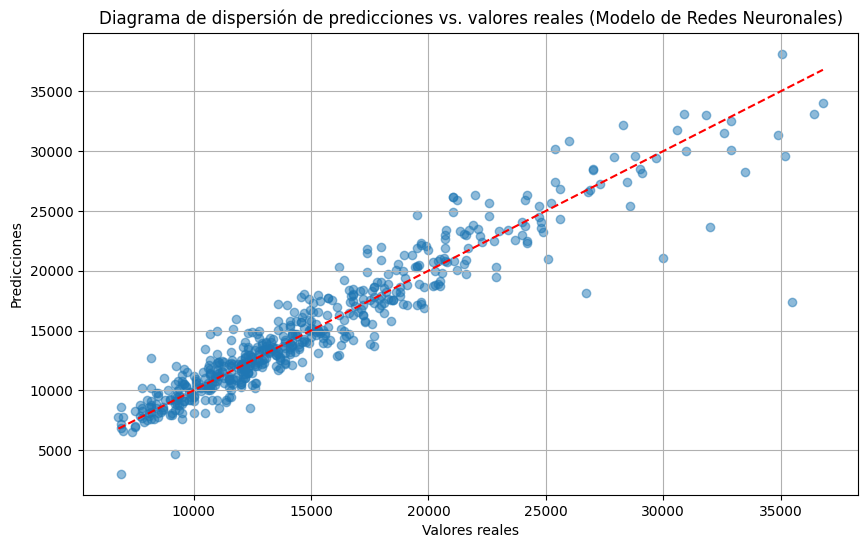




Precisión del modelo Random Forest (R^2): 0.8358412538230723

MAE:  1598.9573774300636


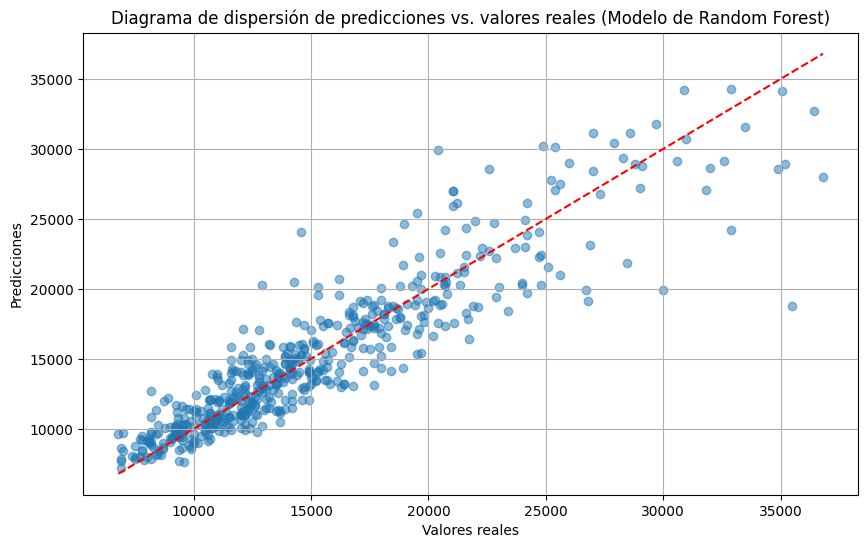




Precisión del modelo Linear Regression (R^2): -1.8743896082177553e+20

MAE:  11463957692327.244


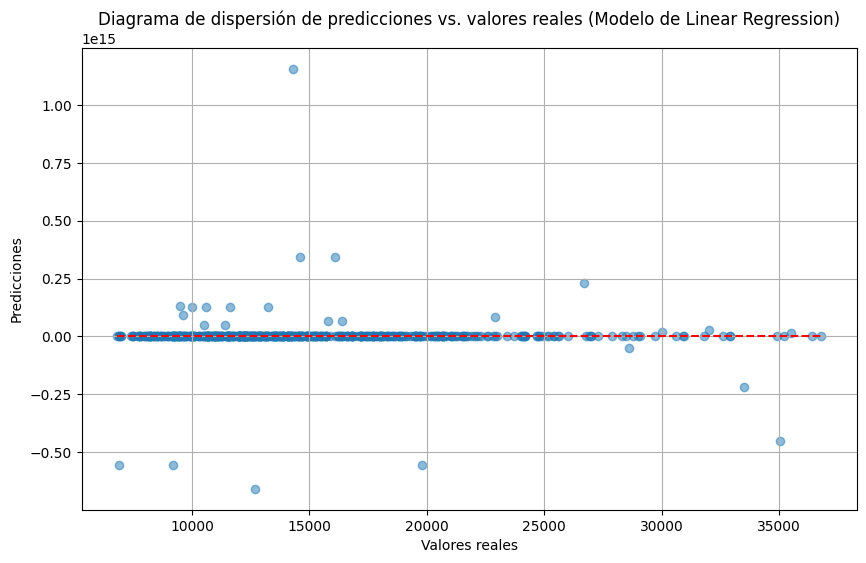

In [ ]:
desplegarResultado(mlp, X_test, y_test, "Redes Neuronales")
print('\n\n')
desplegarResultado(rfr, X_test, y_test, "Random Forest")
print('\n\n')
desplegarResultado(rl, X_test, y_test, "Linear Regression")